In [70]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import quantstats as qs
import warnings
warnings.filterwarnings("ignore")

In [71]:
df = yf.download("AUDCAD=X", start="2010-01-01", end="2026-01-01",auto_adjust=False,multi_level_index=False)

from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Adj Close'])

print('p-value:', result[1])
t_stat = result[0]
critical_value =  result[4]['10%']
print(t_stat<critical_value)

[*********************100%***********************]  1 of 1 completed

p-value: 0.08874567871408595
True


In [72]:
df['ma'] = df['Adj Close'].rolling(10).mean()
df['std'] = df['Adj Close'].rolling(10).std()

df['upper_band'] = df['ma'] + 0.5 * df['std']
df['lower_band'] = df['ma'] - 0.5 * df['std']
df = df[['Adj Close','ma','std','upper_band','lower_band']]
df.rename(columns={'Adj Close':'close'}, inplace=True)

df['long_entry'] = df.close < df.lower_band
df['long_exit'] = df.close > df.ma

df['position_long'] = np.nan
df.loc[df.long_entry, 'position_long'] = 1
df.loc[df.long_exit, 'position_long'] = 0

df.position_long = df.position_long.fillna(method='ffill')

df['short_entry'] = df.close > df.upper_band
df['short_exit'] = df.close < df.ma

df['position_short'] = np.nan
df.loc[df.short_entry, 'position_short'] = 1
df.loc[df.short_exit, 'position_short'] = 0
df.position_short = df.position_short.fillna(method='ffill')

df['positions'] = np.nan
df['positions'] = df.position_long + df.position_short

df['prices_diff'] = df.close - df.close.shift(1)
df['pnl'] = df.positions.shift(1) * df.prices_diff
df['cumpnl'] = df.pnl.cumsum()

df['percentage_change'] = df.close.pct_change()
df['strategy_returns'] = df.positions.shift(1) * df.percentage_change
df['cumulative_returns'] = (df.strategy_returns+1).cumprod()

df.dropna(inplace=True)



Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Strategy
-------------------------  ----------
Start Period               2010-01-18
End Period                 2025-12-31
Risk-Free Rate             0.0%
Time in Market             90.0%

Cumulative Return          -6.86%
CAGR﹪                     -0.43%

Sharpe                     -0.02
Prob. Sharpe Ratio         46.01%
Smart Sharpe               -0.02
Sortino                    -0.03
Smart Sortino              -0.03
Sortino/√2                 -0.02
Smart Sortino/√2           -0.02
Omega                      1.0

Max Drawdown               -23.34%
Max DD Date                2020-03-23
Max DD Period Start        2011-10-27
Max DD Period End          2025-12-31
Longest DD Days            5180
Volatility (ann.)          7.14%
Calmar                     -0.02
Skew                       -0.31
Kurtosis                   3.66
Ulcer Perf

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2011-10-27,2020-03-23,2025-12-31,5180,-23.341389,-20.359970
2,2010-01-26,2010-06-07,2010-09-01,219,-10.290637,-9.245239
3,2010-12-31,2011-03-18,2011-04-27,118,-5.636573,-5.324757
4,2011-09-06,2011-10-04,2011-10-25,50,-5.026251,-4.959955
5,2011-08-02,2011-08-09,2011-08-30,29,-3.366252,-3.145175


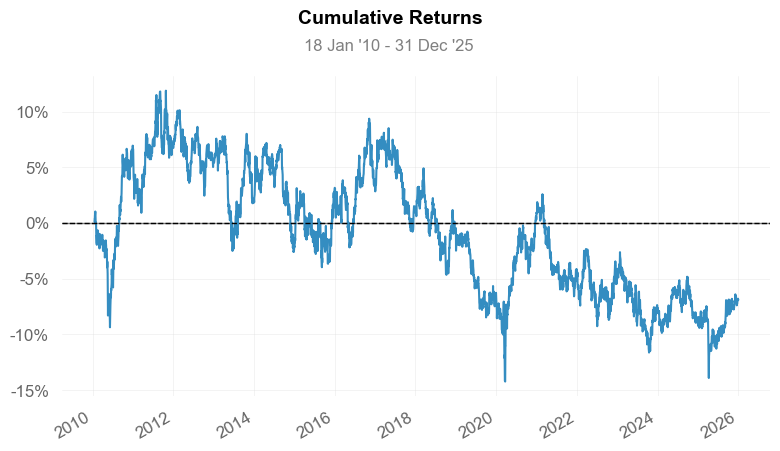

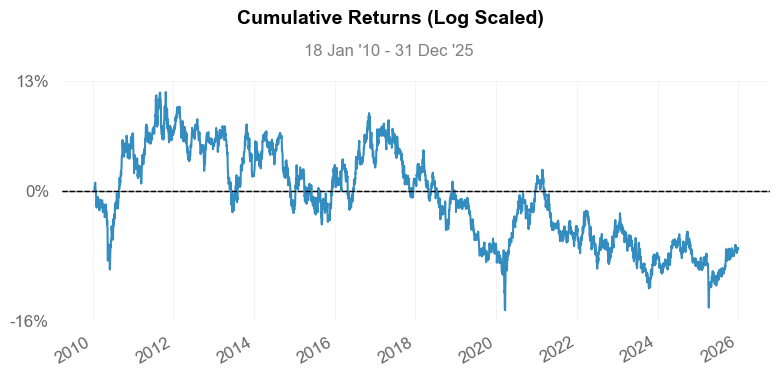

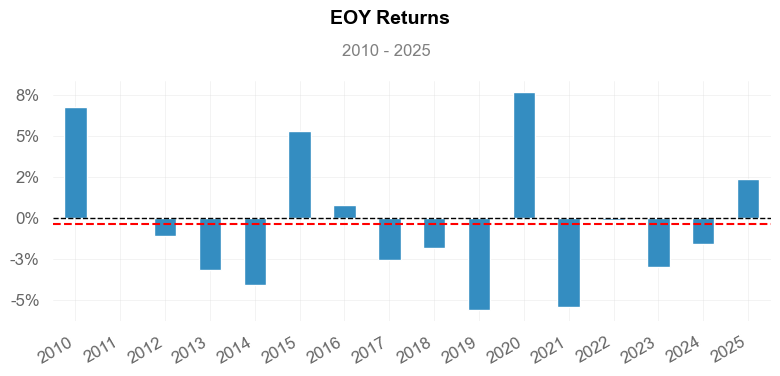

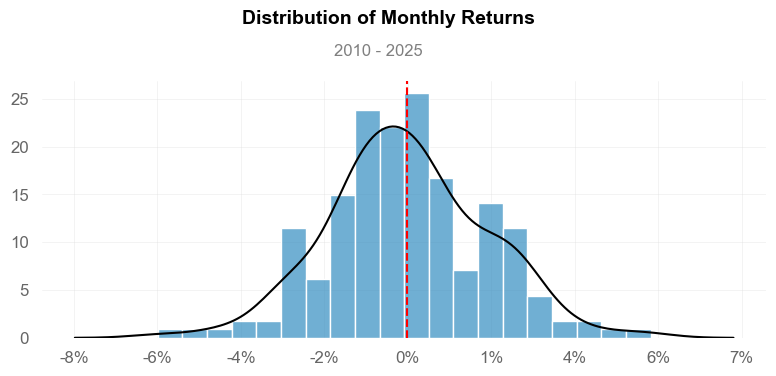

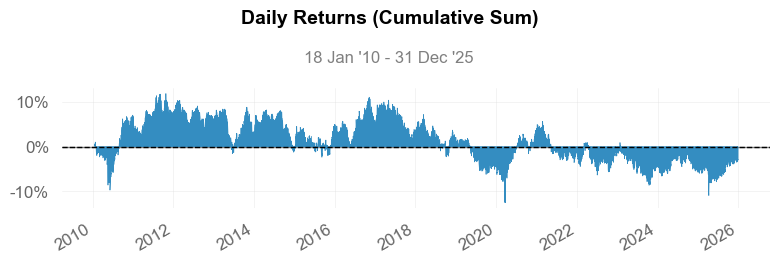

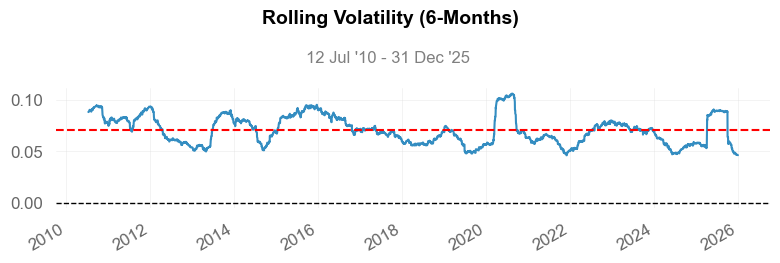

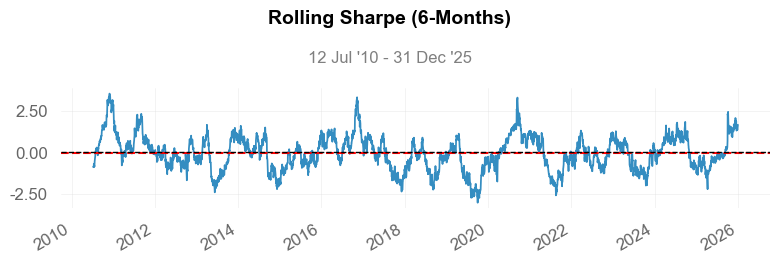

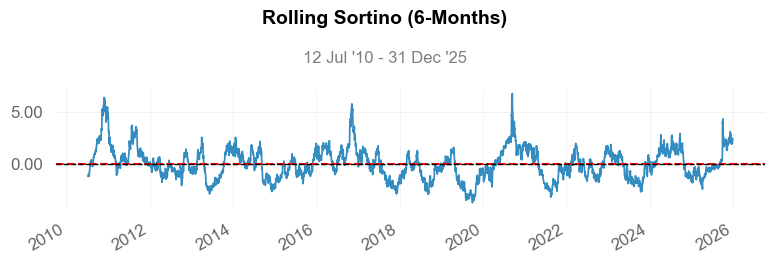

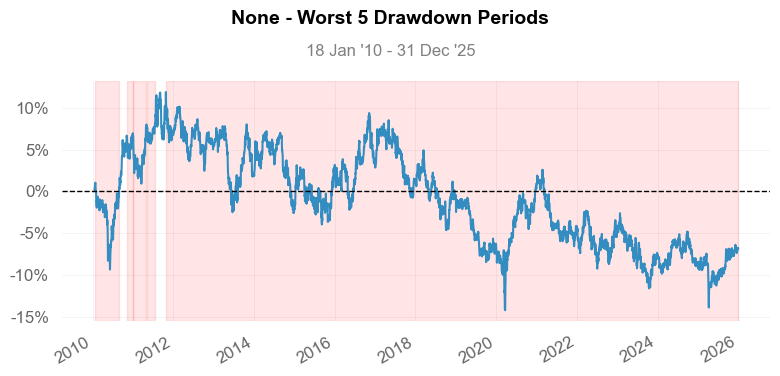

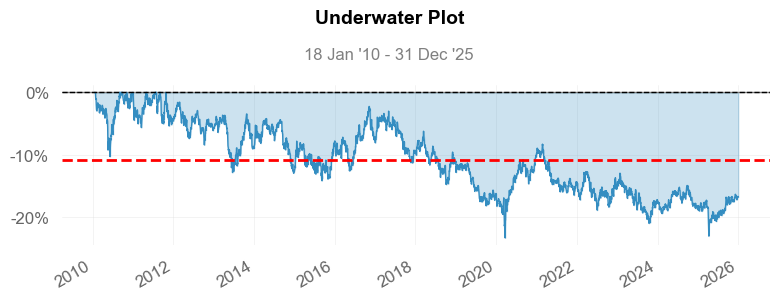

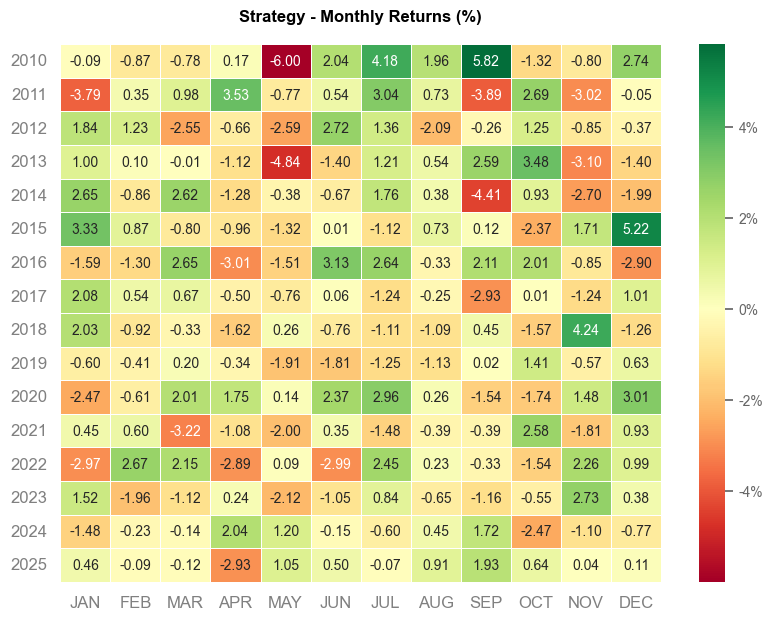

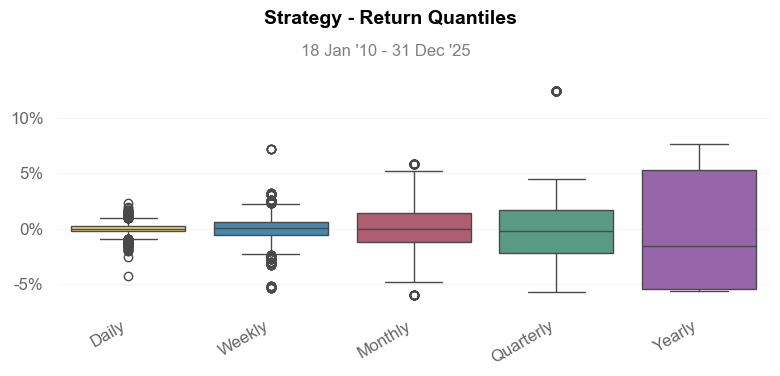

In [73]:
qs.reports.full(df['strategy_returns'].dropna())